In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pingouin as pg

Analyze Univariée

In [3]:
stroke_path =r"C:\Users\f.gionnane\Documents\TechnoFuturTIC\EDA\stroke.csv"

# Load the dataset
stroke_data = pd.read_csv(stroke_path,index_col='id')

# Display the first few rows of the dataset
stroke_data.head()

# Check for missing values
missing_values = stroke_data.isnull().sum()

missing_values

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [4]:
stroke_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 9046 to 44679
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.1+ KB


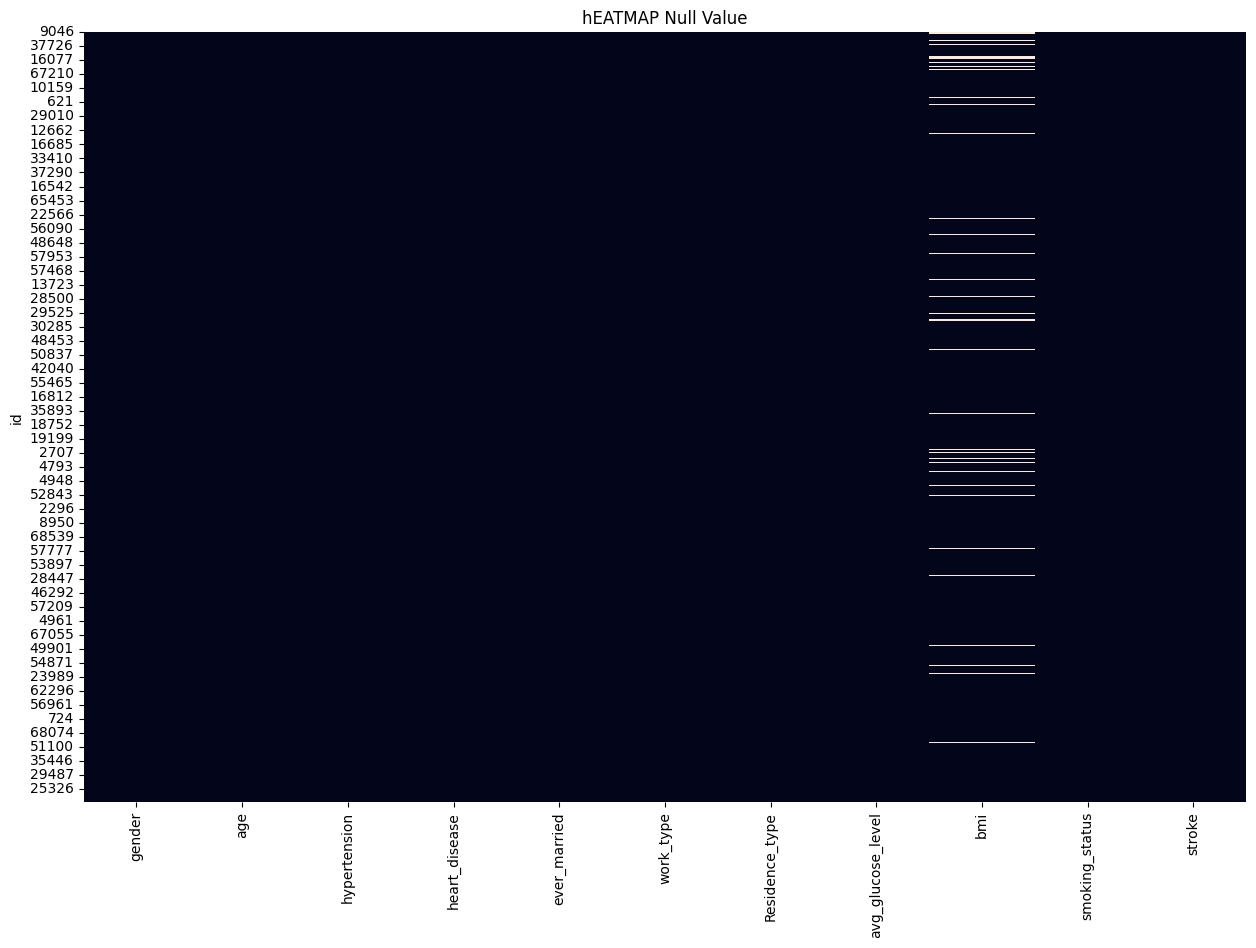

In [5]:
FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('hEATMAP Null Value')
sns.heatmap(stroke_data.isna(), cbar=False)
plt.show()

In [6]:
cont_feature = stroke_data.select_dtypes(include=float)
cont_feature

,age,avg_glucose_level,bmi
id,,,
9046,67.0,228.69,36.6
51676,61.0,202.21,NaN
31112,80.0,105.92,32.5
60182,49.0,171.23,34.4
1665,79.0,174.12,24.0
...,...,...,...
18234,80.0,83.75,NaN
44873,81.0,125.20,40.0
19723,35.0,82.99,30.6


In [7]:
cat_feature = stroke_data.select_dtypes(exclude=float)
cat_feature

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,stroke
id,,,,,,,,
9046,Male,0,1,Yes,Private,Urban,formerly smoked,1
51676,Female,0,0,Yes,Self-employed,Rural,never smoked,1
31112,Male,0,1,Yes,Private,Rural,never smoked,1
60182,Female,0,0,Yes,Private,Urban,smokes,1
1665,Female,1,0,Yes,Self-employed,Rural,never smoked,1
...,...,...,...,...,...,...,...,...
18234,Female,1,0,Yes,Private,Urban,never smoked,0
44873,Female,0,0,Yes,Self-employed,Urban,never smoked,0
19723,Female,0,0,Yes,Self-employed,Rural,never smoked,0


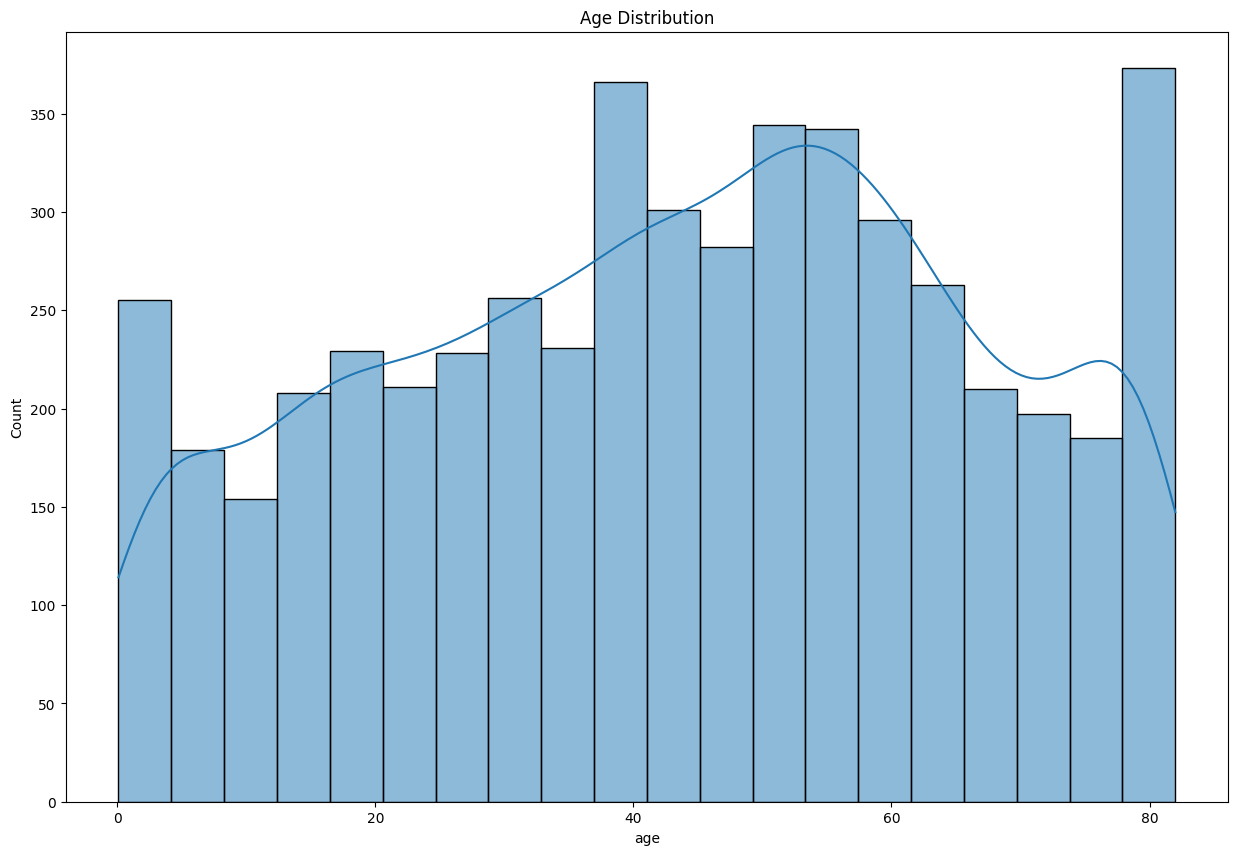

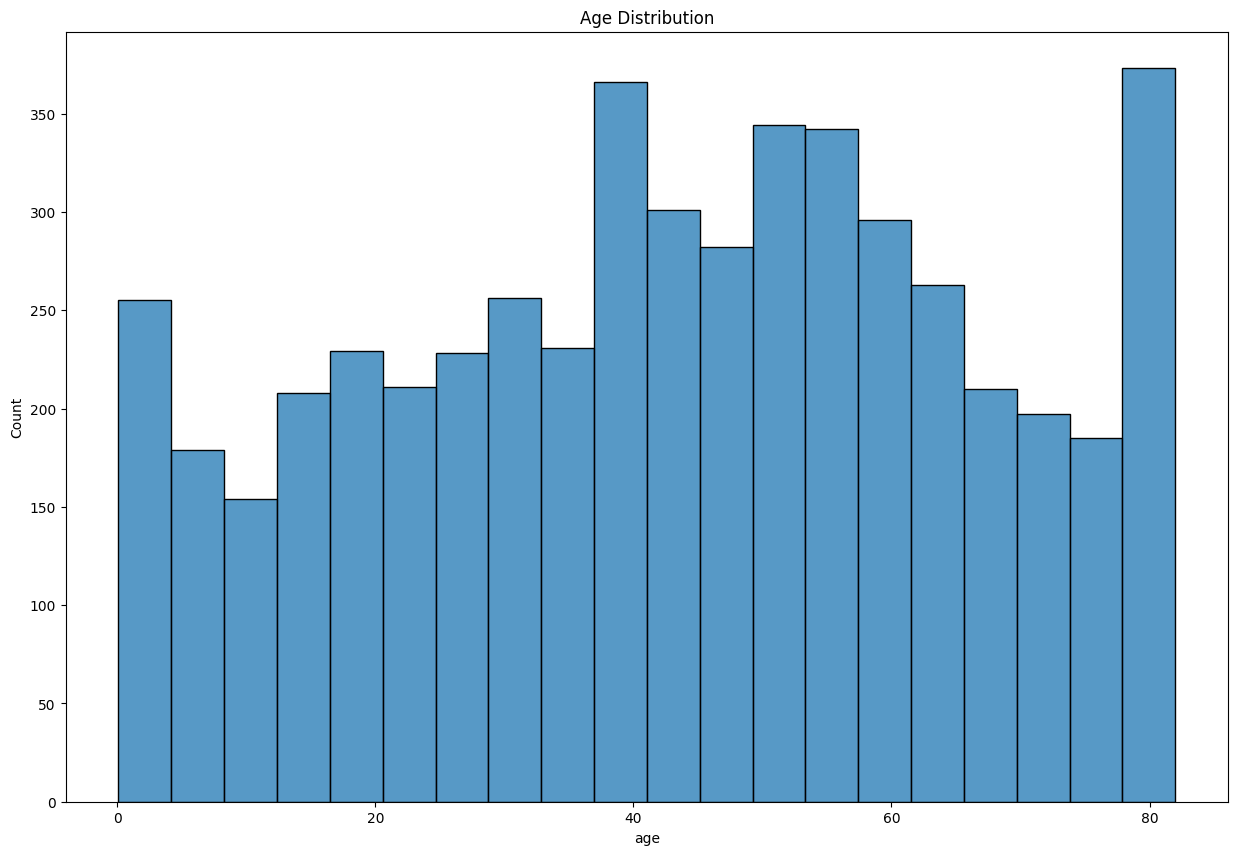

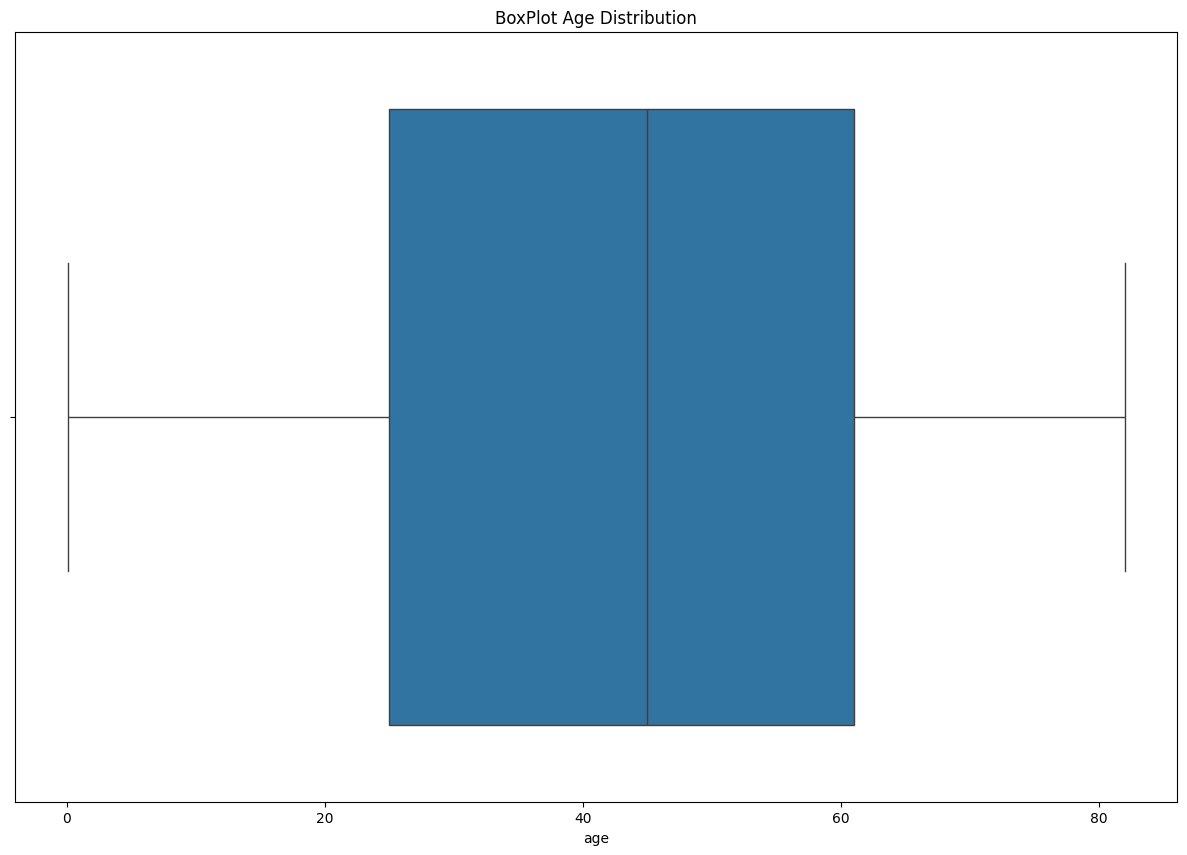

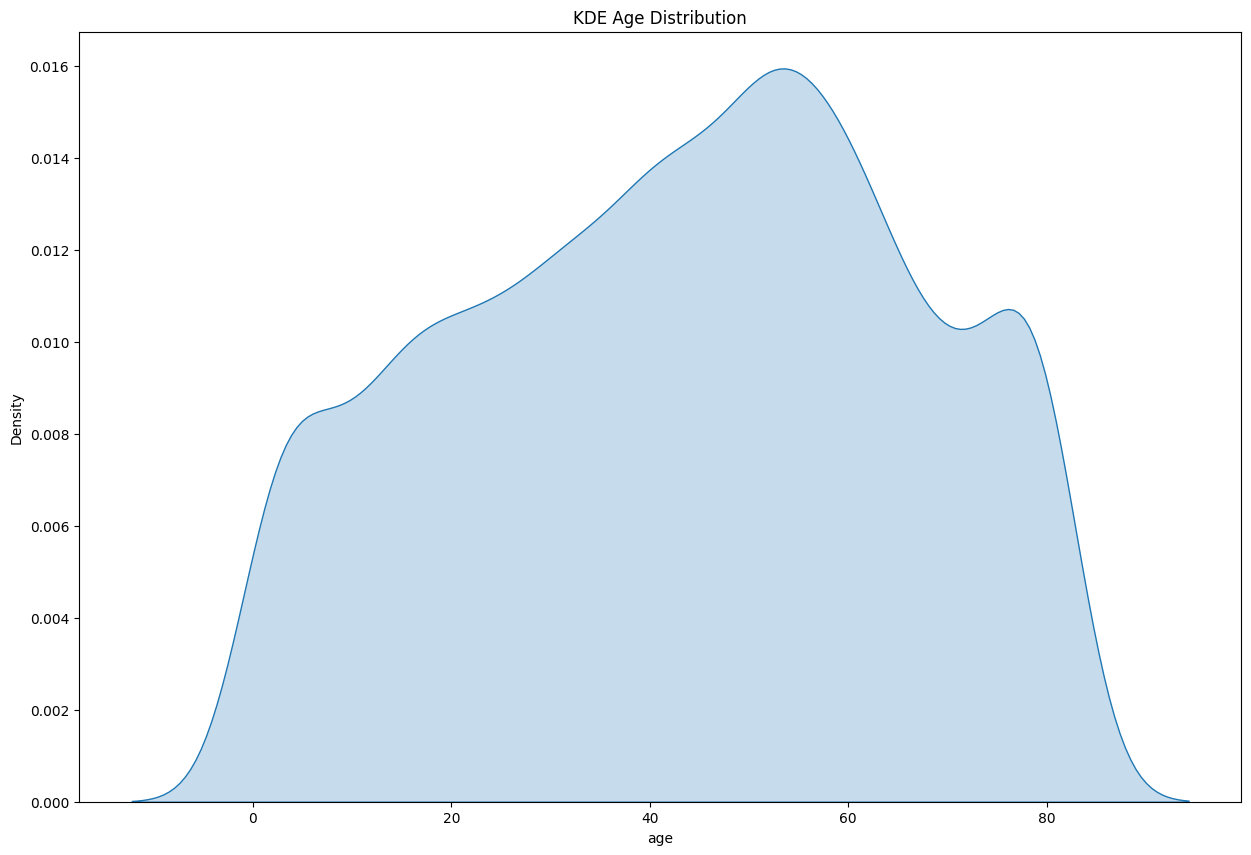

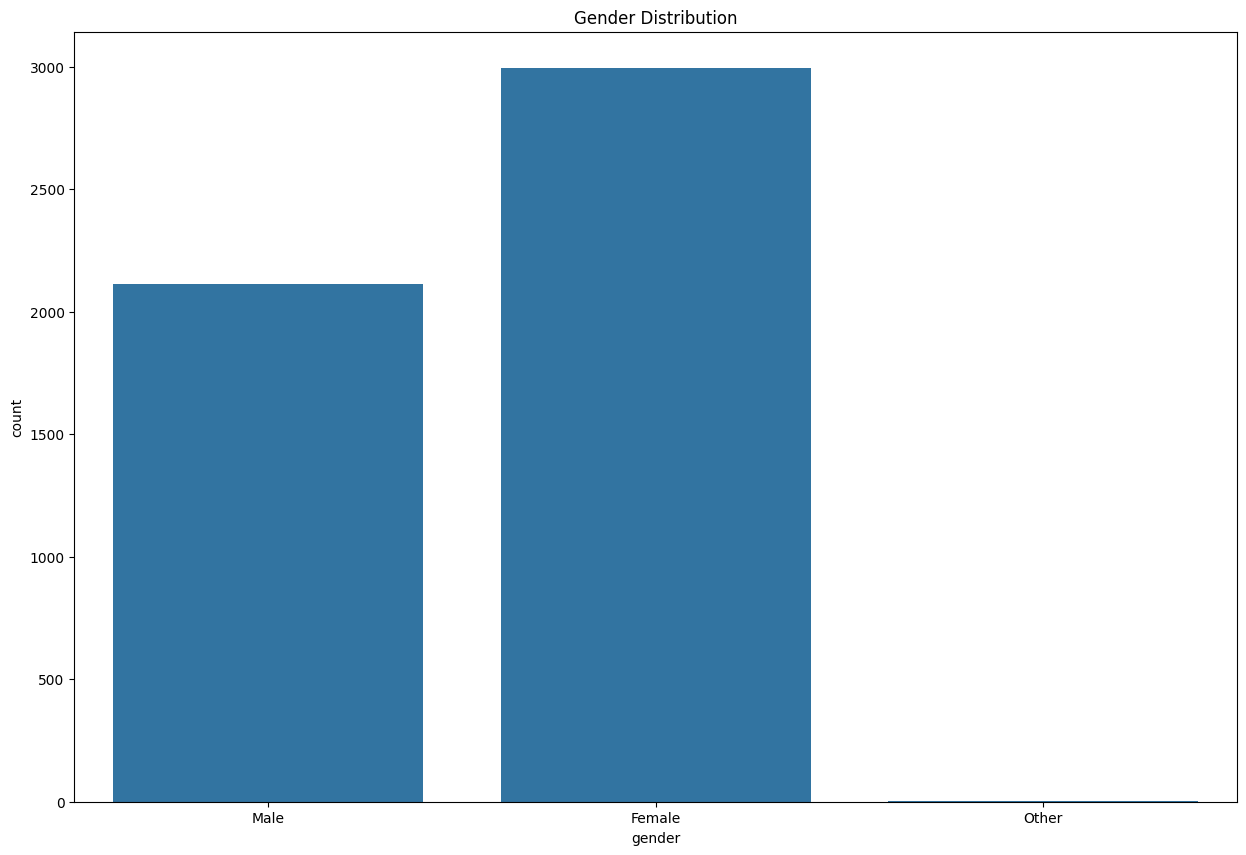

In [20]:
FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('Age Distribution')
sns.histplot(data =stroke_data, x="age", kde=True)
plt.show()

FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('Age Distribution')
sns.histplot(data =stroke_data, x="age", fill=True)
plt.show()

FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('BoxPlot Age Distribution')
sns.boxplot(data =stroke_data, x="age", fill=True)
plt.show()

FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('KDE Age Distribution')
sns.kdeplot(data =stroke_data, x="age", fill=True)
plt.show()

FIGSIZE = (15, 10)
plt.figure(figsize=FIGSIZE)
plt.title('Gender Distribution')
sns.countplot(data =stroke_data, x="gender", fill=True)
plt.show()



Analyse bivariée

In [ ]:
crossgenre = pd.crosstab(stroke_data['gender'], stroke_data['stroke'], normalize='columns')

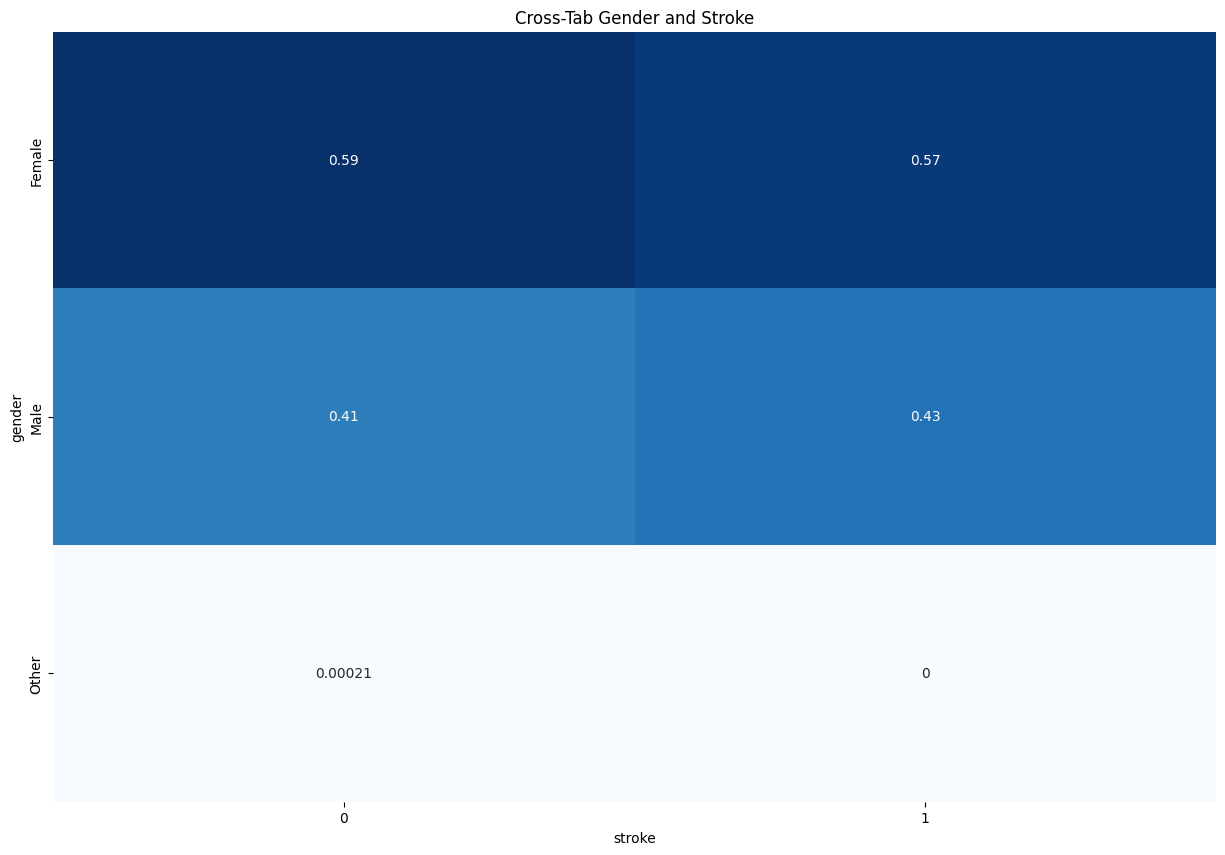

In [40]:
plt.figure(figsize=FIGSIZE)
plt.title('Cross-Tab Gender and Stroke')
sns.heatmap(crossgenre, cbar=False, annot=True, cmap='Blues')
plt.show()

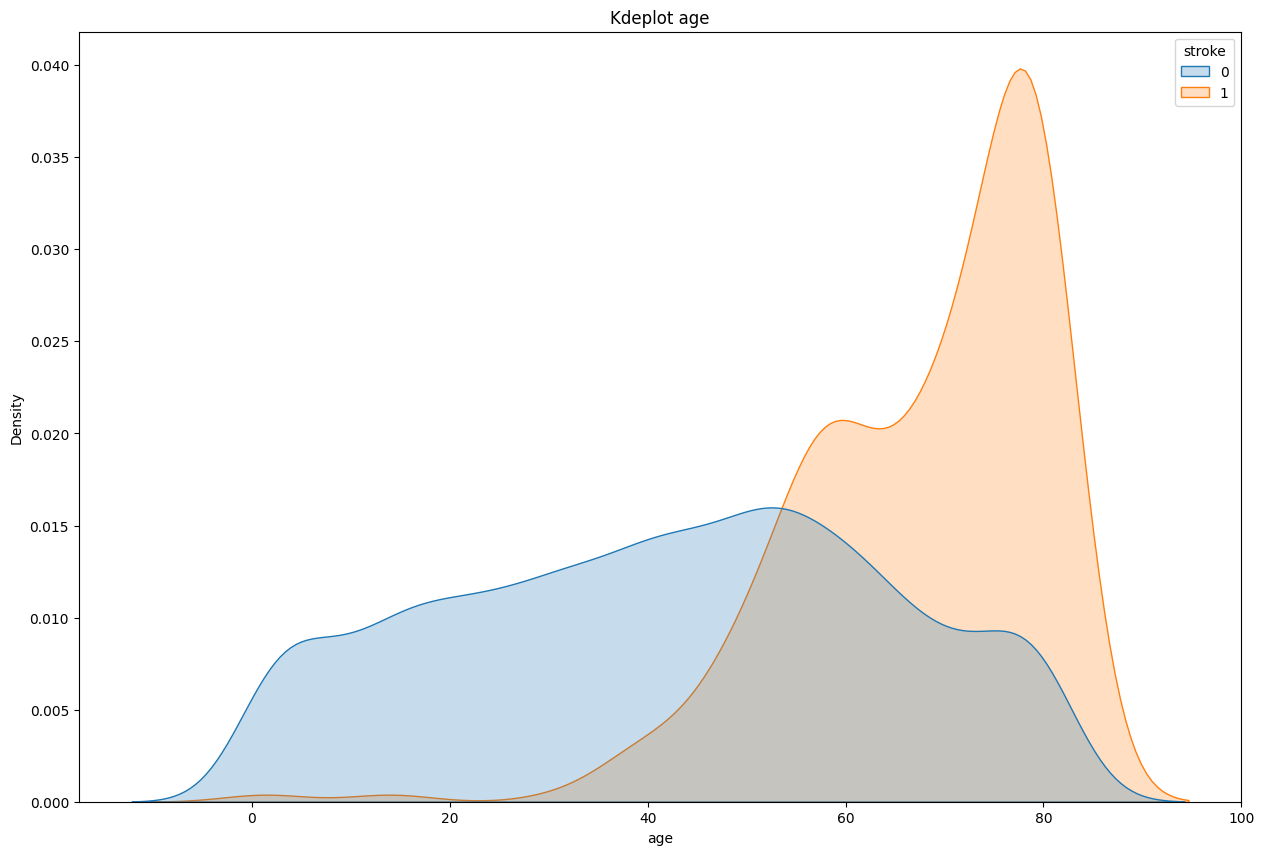

In [42]:
plt.figure(figsize=FIGSIZE)
plt.title('Kdeplot age')
sns.kdeplot(data=stroke_data, x="age", fill=True, hue= 'stroke', common_norm=False)
plt.show()

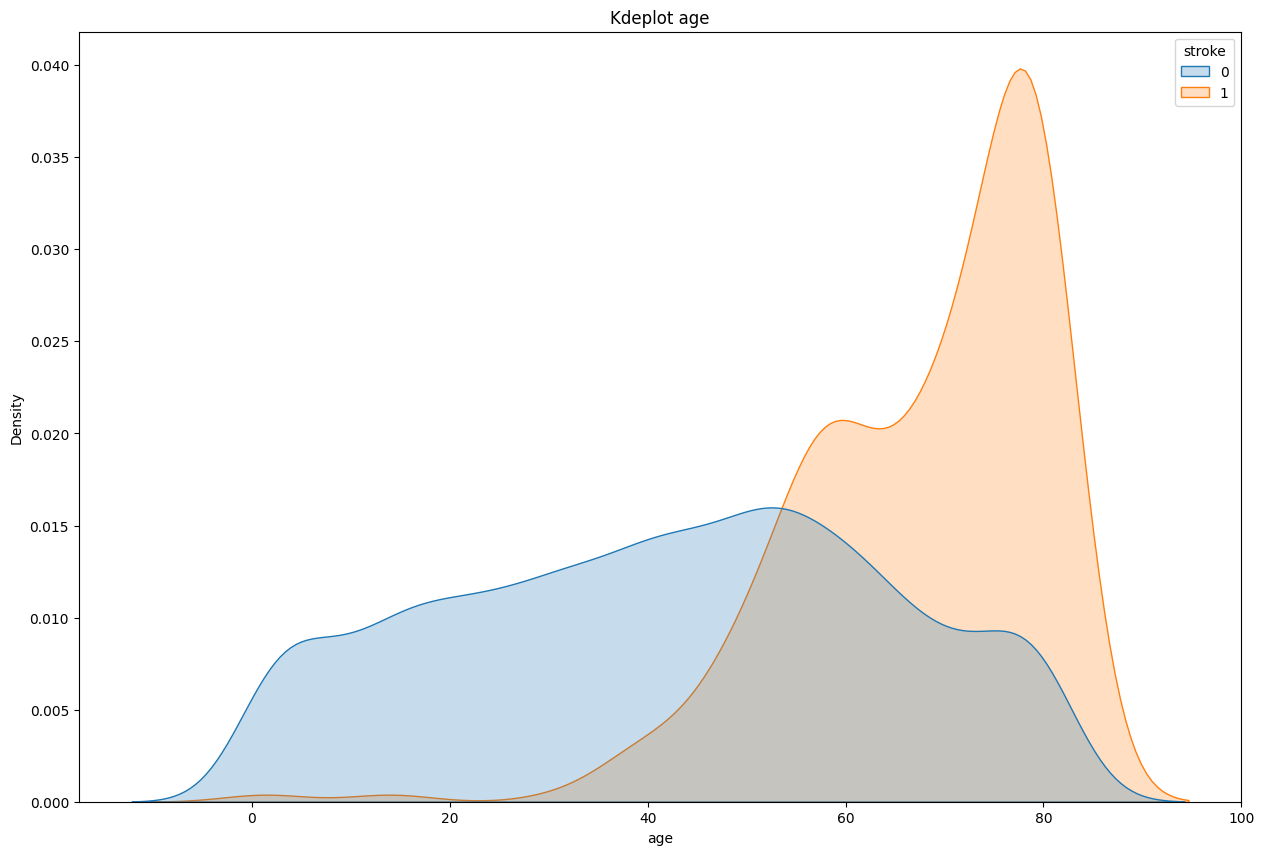

age                                                    
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4861.0  41.971545  22.291940  0.08  24.0  43.0  59.0  82.0
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0

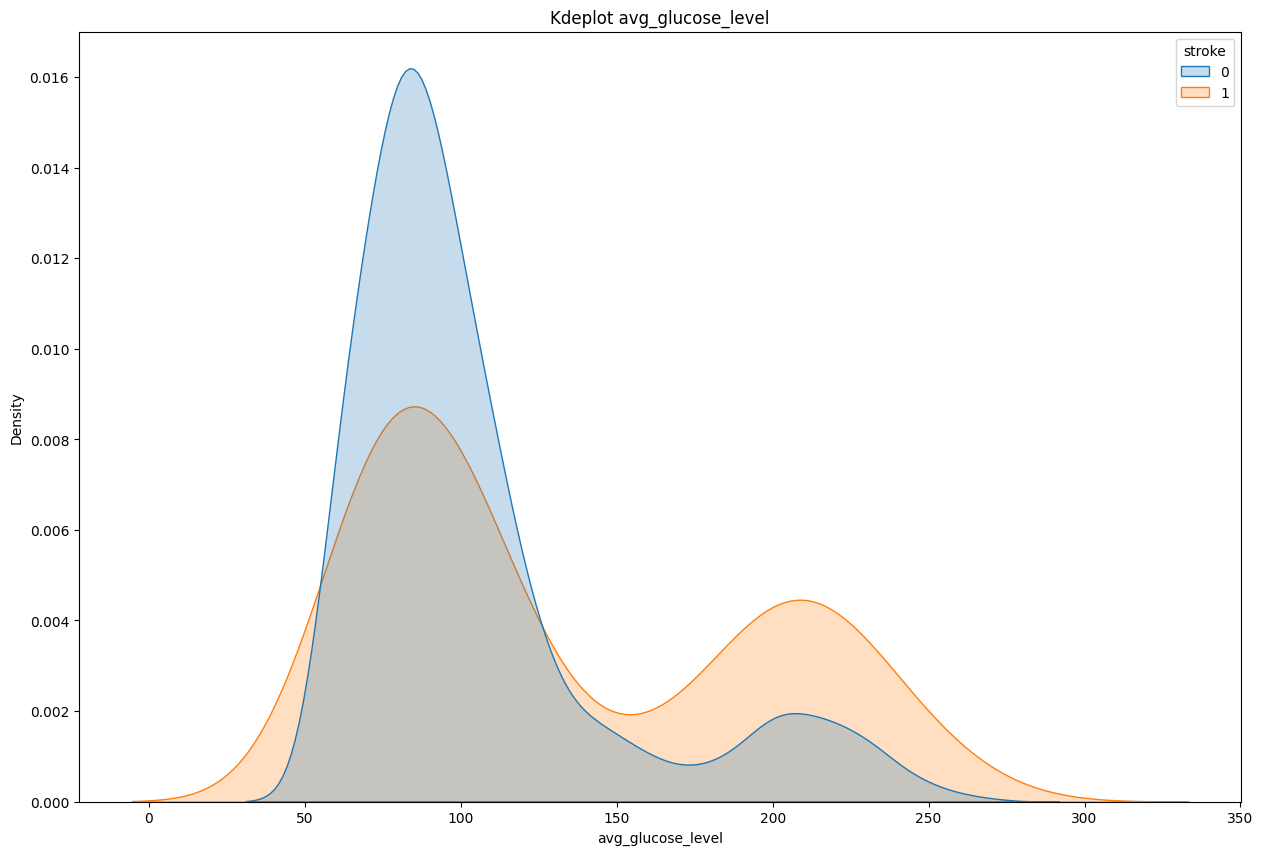

avg_glucose_level                                                       \
                   count        mean        std    min    25%     50%     75%   
stroke                                                                          
0                 4861.0  104.795513  43.846069  55.12  77.12   91.47  112.83   
1                  249.0  132.544739  61.921056  56.11  79.79  105.22  196.71   

                
           max  
stroke          
0       267.76  
1       271.74

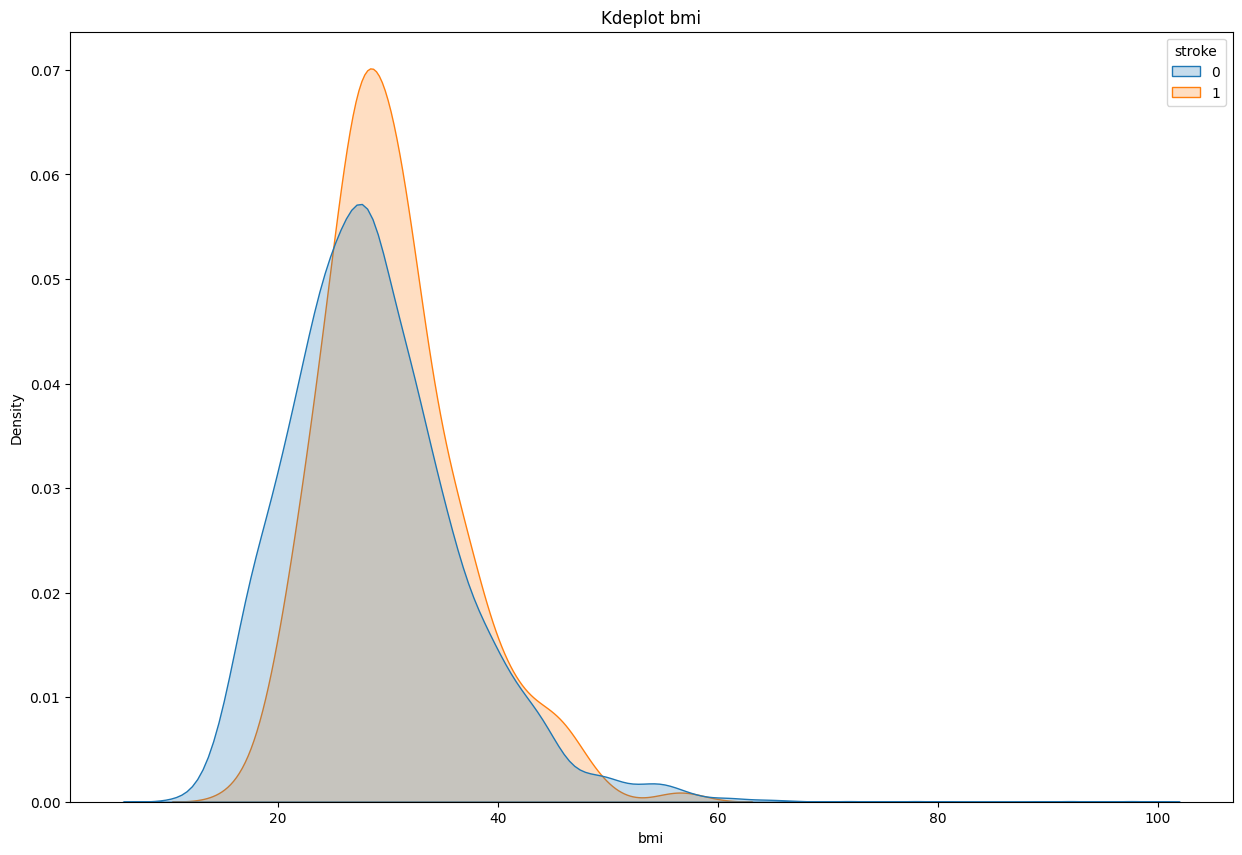

bmi                                                   
         count       mean       std   min   25%   50%   75%   max
stroke                                                           
0       4700.0  28.823064  7.908287  10.3  23.4  28.0  33.1  97.6
1        209.0  30.471292  6.329452  16.9  26.4  29.7  33.7  56.6

In [45]:
for col in cont_feature.columns:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'Kdeplot {col}')
    sns.kdeplot(data=stroke_data, x=col, fill=True, hue='stroke', common_norm=False)
    plt.show()
    display(stroke_data[[col, 'stroke']].groupby('stroke').describe())

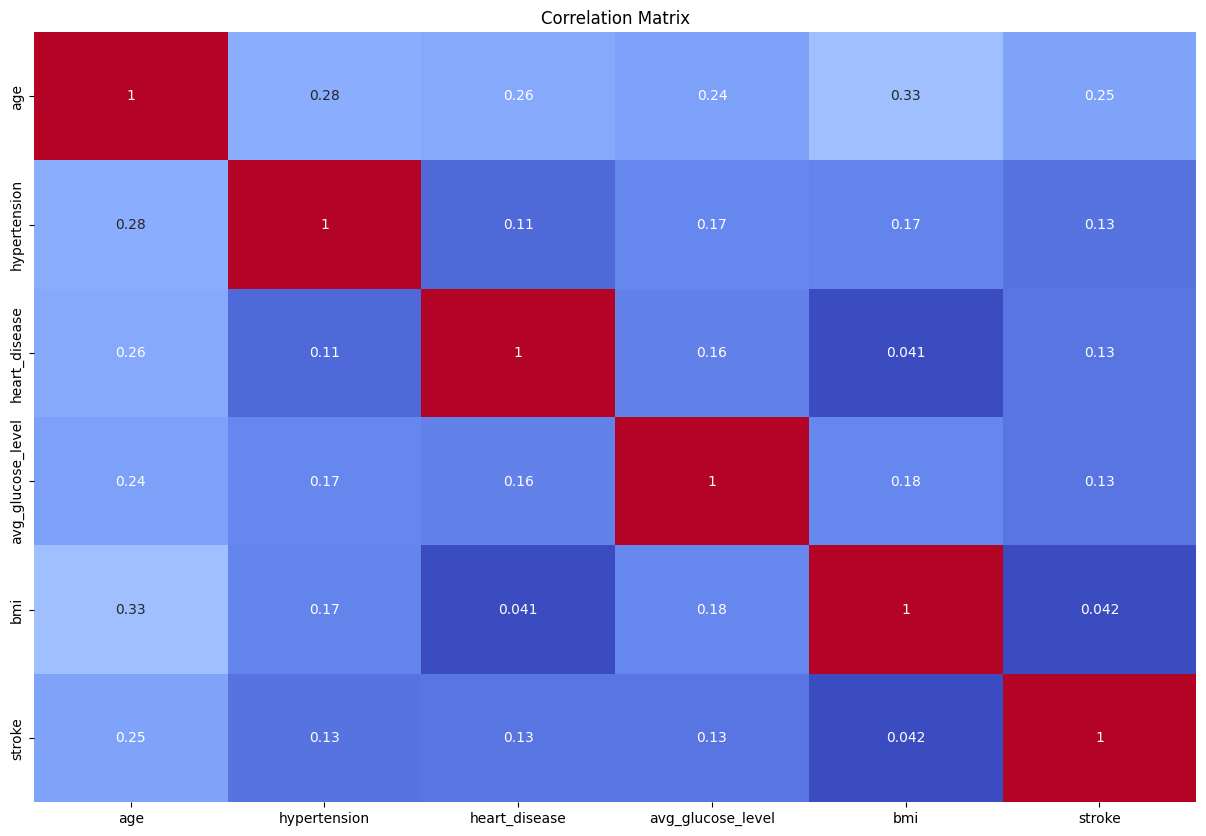

In [48]:
# Matrice de corrélation

plt.figure(figsize=FIGSIZE)
plt.title('Correlation Matrix')
sns.heatmap(stroke_data.corr(numeric_only=True),cbar=False, annot=True, cmap='coolwarm')
plt.show()

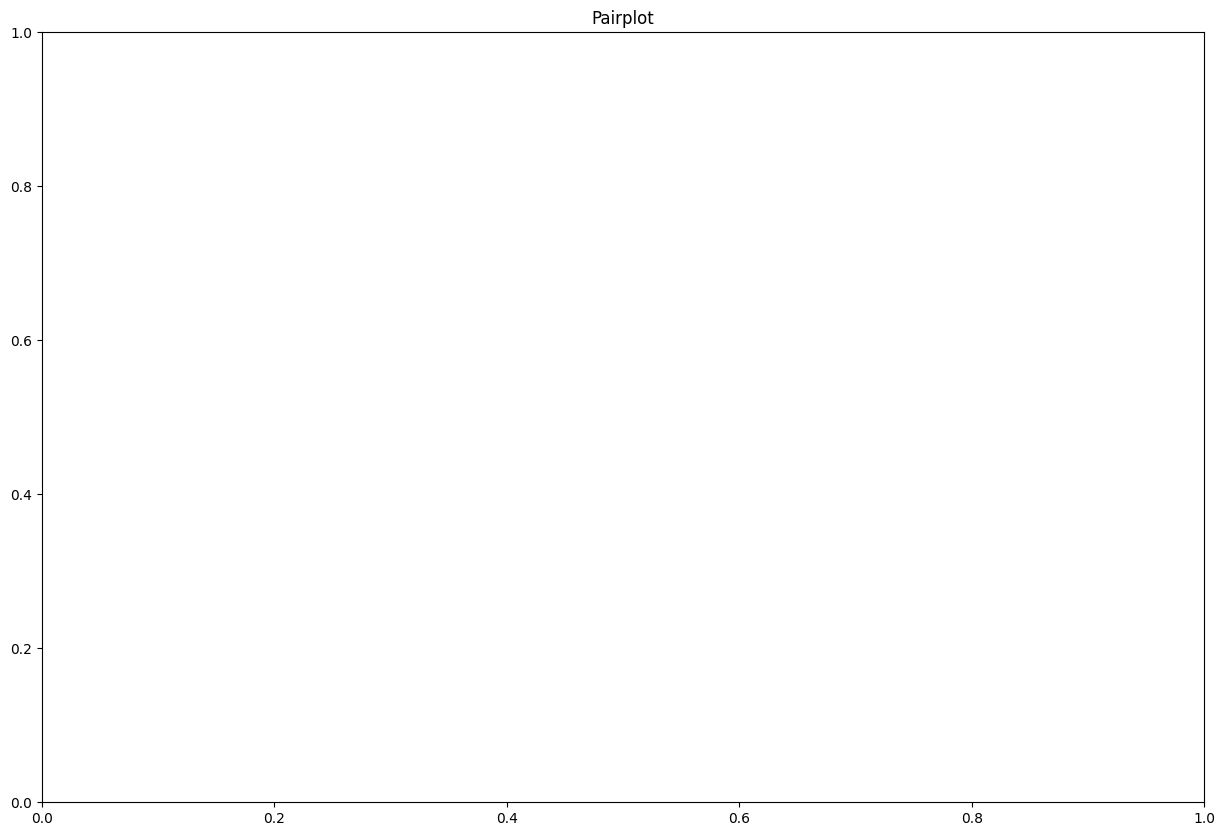

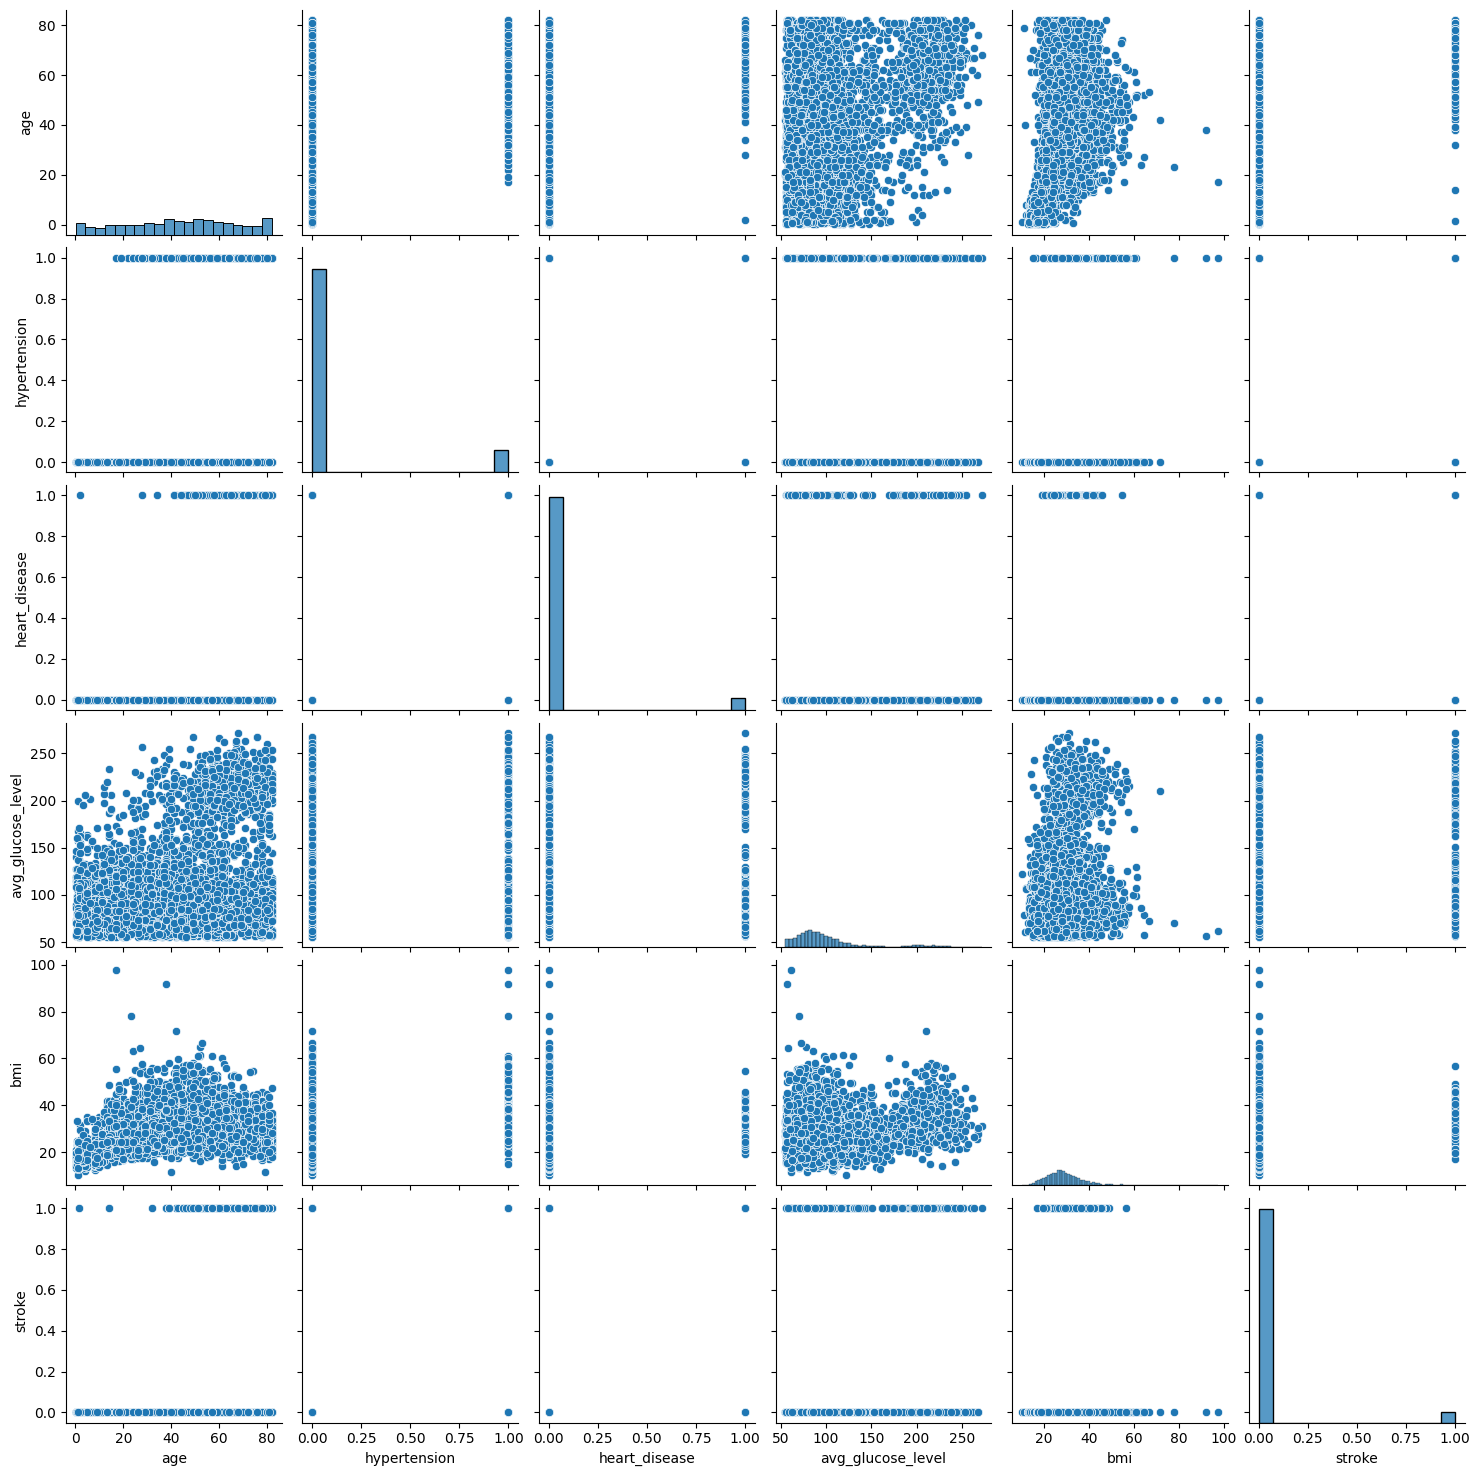

In [49]:
plt.figure(figsize=FIGSIZE)
plt.title('Pairplot')
sns.pairplot(stroke_data)
plt.show()